# Simple Ensemble - Weighted Average of 3 Models

## Overview
This notebook combines predictions from three hybrid models for the ISIC competition:

1. **Baseline Hybrid** (Custom CNN + Metadata) - Val AUC: 0.9365, LB: 0.92731
2. **ResNet34 Hybrid** - Val AUC: 0.9380, LB: 0.92982  
3. **EfficientNetV2-S Hybrid** - Val AUC: 0.9508, LB: 0.93734

**Strategy**: Weighted average (give more weight to better models)
**Expected improvement**: +0.005-0.010 AUC
**Target**: 2nd place (0.945)

In [1]:
# Import Required Libraries and Setup
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import json

print("="*70)
print("MODEL ENSEMBLE - WEIGHTED AVERAGE")
print("="*70)
print("\nCombining 3 hybrid models for improved predictions")
print("="*70 + "\n")

MODEL ENSEMBLE - WEIGHTED AVERAGE

Combining 3 hybrid models for improved predictions



## 1. Load All Model Submissions

Load the submission files from the three hybrid models and verify they have matching ISIC IDs.

In [2]:
# Load All Model Submissions
results_base = Path('results')

# Automatically find the latest results directories
def find_latest_result(pattern):
    """Find most recent results folder matching pattern"""
    folders = sorted(results_base.glob(pattern))
    if not folders:
        raise ValueError(f"No results found for pattern: {pattern}")
    return folders[-1]

# Find latest results for each model
baseline_dir = find_latest_result('hybrid_model_*')
resnet_dir = find_latest_result('resnet34_hybrid_*')
efficientnet_dir = find_latest_result('efficientnet_v2_hybrid_*')

print("Loading submissions from:")
print(f"  1. Baseline:     {baseline_dir}")
print(f"  2. ResNet34:     {resnet_dir}")
print(f"  3. EfficientNet: {efficientnet_dir}\n")

# Load submission files
baseline_sub = pd.read_csv(baseline_dir / 'submission_hybrid_model.csv')
resnet_sub = pd.read_csv(resnet_dir / 'submission_resnet34_hybrid.csv')
efficientnet_sub = pd.read_csv(efficientnet_dir / 'submission_efficientnet_v2_hybrid.csv')

# Verify all have same IDs in same order
assert (baseline_sub['isic_id'] == resnet_sub['isic_id']).all(), "ID mismatch!"
assert (baseline_sub['isic_id'] == efficientnet_sub['isic_id']).all(), "ID mismatch!"

print(f"✓ All submissions loaded successfully")
print(f"  Shape: {baseline_sub.shape}")
print(f"  Test samples: {len(baseline_sub)}\n")

Loading submissions from:
  1. Baseline:     results/hybrid_model_20251107_161422
  2. ResNet34:     results/resnet34_hybrid_20251107_182054
  3. EfficientNet: results/efficientnet_v2_hybrid_20251107_182005

✓ All submissions loaded successfully
  Shape: (100, 2)
  Test samples: 100



## 2. Analyze Individual Model Predictions

Examine the prediction statistics for each model including validation AUC, public LB scores, and distribution metrics.

In [3]:
# Analyze Individual Model Predictions
print("="*70)
print("INDIVIDUAL MODEL ANALYSIS")
print("="*70 + "\n")

models_data = {
    'Baseline': {'preds': baseline_sub['target'].values, 'val_auc': 0.9365, 'lb': 0.92731},
    'ResNet34': {'preds': resnet_sub['target'].values, 'val_auc': 0.9380, 'lb': 0.92982},
    'EfficientNetV2': {'preds': efficientnet_sub['target'].values, 'val_auc': 0.9508, 'lb': 0.93734}
}

for name, data in models_data.items():
    preds = data['preds']
    print(f"{name}:")
    print(f"  Val AUC: {data['val_auc']:.4f}")
    print(f"  Public LB: {data['lb']:.5f}")
    print(f"  Predictions - Mean: {preds.mean():.6f}, Std: {preds.std():.6f}")
    print(f"  Predictions - Min: {preds.min():.6f}, Max: {preds.max():.6f}\n")

INDIVIDUAL MODEL ANALYSIS

Baseline:
  Val AUC: 0.9365
  Public LB: 0.92731
  Predictions - Mean: 0.088968, Std: 0.074839
  Predictions - Min: 0.010869, Max: 0.242053

ResNet34:
  Val AUC: 0.9380
  Public LB: 0.92982
  Predictions - Mean: 0.085471, Std: 0.085109
  Predictions - Min: 0.003471, Max: 0.269203

EfficientNetV2:
  Val AUC: 0.9508
  Public LB: 0.93734
  Predictions - Mean: 0.115752, Std: 0.084461
  Predictions - Min: 0.016252, Max: 0.335337



## 3. Visualize Individual Model Distributions

Create histograms to visualize the prediction distributions for each model and compare their characteristics.

✓ Prediction distributions plotted



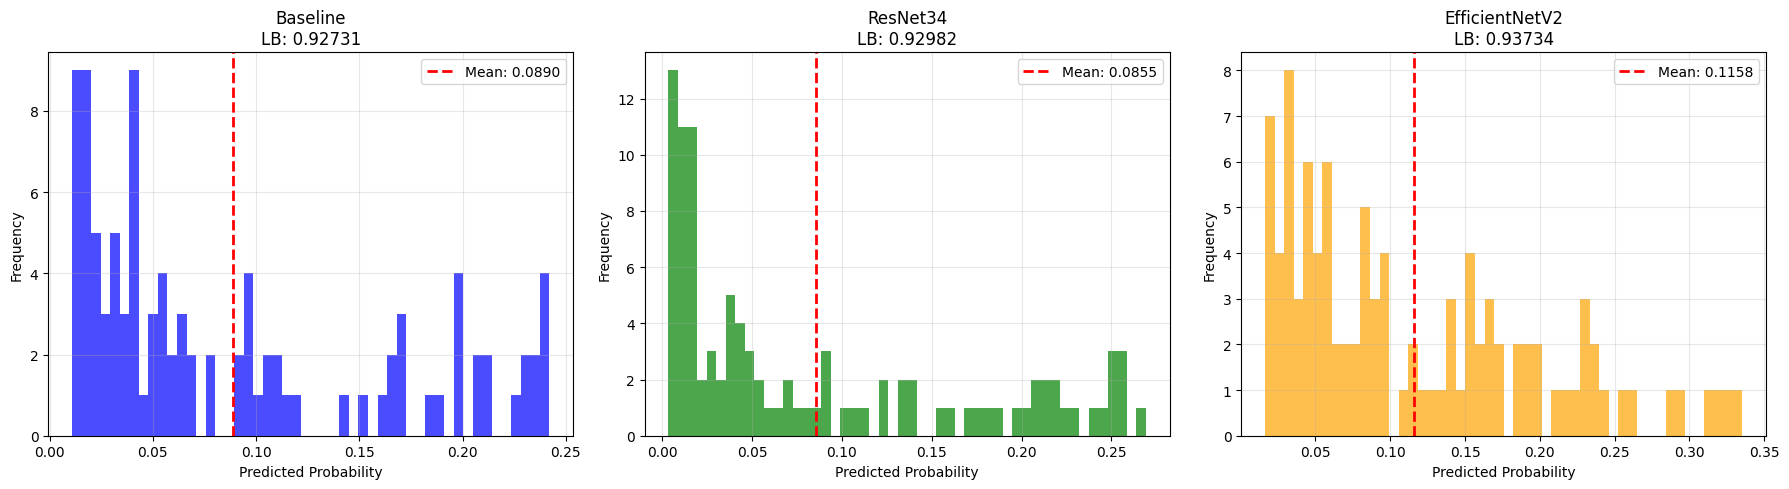

In [4]:
# Visualize Individual Model Distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, data) in enumerate(models_data.items()):
    axes[idx].hist(data['preds'], bins=50, alpha=0.7, color=['blue', 'green', 'orange'][idx])
    axes[idx].axvline(data['preds'].mean(), color='red', linestyle='--', 
                      linewidth=2, label=f'Mean: {data["preds"].mean():.4f}')
    axes[idx].set_xlabel('Predicted Probability')
    axes[idx].set_ylabel('Frequency')
    axes[idx].set_title(f'{name}\nLB: {data["lb"]:.5f}')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('model_predictions_comparison.png', dpi=150, bbox_inches='tight')
print("✓ Prediction distributions plotted\n")
plt.show()

## 4. Analyze Prediction Correlations

Calculate and visualize the correlation between model predictions to understand how similar or different their predictions are.

PREDICTION CORRELATION ANALYSIS

Correlation between model predictions:
                Baseline  ResNet34  EfficientNetV2
Baseline        1.000000  0.959922        0.926127
ResNet34        0.959922  1.000000        0.927426
EfficientNetV2  0.926127  0.927426        1.000000

✓ Correlation matrix plotted



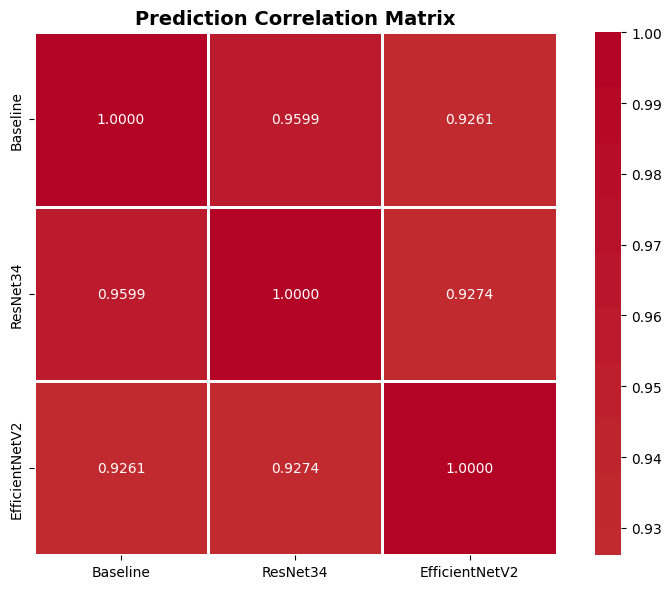

Correlation interpretation:
  - High correlation (>0.95): Models make similar predictions
  - Low correlation (<0.80): Models are complementary (good for ensemble!)



In [5]:
# Analyze Prediction Correlations
print("="*70)
print("PREDICTION CORRELATION ANALYSIS")
print("="*70 + "\n")

# Create correlation matrix
pred_df = pd.DataFrame({
    'Baseline': baseline_sub['target'],
    'ResNet34': resnet_sub['target'],
    'EfficientNetV2': efficientnet_sub['target']
})

correlation_matrix = pred_df.corr()
print("Correlation between model predictions:")
print(correlation_matrix)
print()

# Visualize correlation
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, fmt='.4f', cmap='coolwarm', 
            center=0, square=True, linewidths=1)
plt.title('Prediction Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150, bbox_inches='tight')
print("✓ Correlation matrix plotted\n")
plt.show()

# Interpretation
print("Correlation interpretation:")
print("  - High correlation (>0.95): Models make similar predictions")
print("  - Low correlation (<0.80): Models are complementary (good for ensemble!)")
print()

## 5. Create Weighted Ensemble Predictions

Implement four different ensemble strategies and calculate predictions for each approach.

In [6]:
# Create Weighted Ensemble Predictions
print("="*70)
print("CREATING ENSEMBLE PREDICTIONS")
print("="*70 + "\n")

# Strategy 1: Simple Average (equal weight)
ensemble_simple = (
    baseline_sub['target'] + 
    resnet_sub['target'] + 
    efficientnet_sub['target']
) / 3

# Strategy 2: Weighted by Validation AUC
val_aucs = np.array([0.9365, 0.9380, 0.9508])
weights_val = val_aucs / val_aucs.sum()  # Normalize to sum to 1

ensemble_weighted_val = (
    weights_val[0] * baseline_sub['target'] + 
    weights_val[1] * resnet_sub['target'] + 
    weights_val[2] * efficientnet_sub['target']
)

# Strategy 3: Weighted by Public Leaderboard Score
lb_scores = np.array([0.92731, 0.92982, 0.93734])
weights_lb = lb_scores / lb_scores.sum()

ensemble_weighted_lb = (
    weights_lb[0] * baseline_sub['target'] + 
    weights_lb[1] * resnet_sub['target'] + 
    weights_lb[2] * efficientnet_sub['target']
)

# Strategy 4: Best model only (EfficientNetV2) with 70%, others 15% each
ensemble_best_heavy = (
    0.15 * baseline_sub['target'] + 
    0.15 * resnet_sub['target'] + 
    0.70 * efficientnet_sub['target']
)

print("Ensemble strategies:")
print(f"\n1. Simple Average (equal weights: 0.333, 0.333, 0.333)")
print(f"   Weights: [0.333, 0.333, 0.333]")
print(f"   Mean: {ensemble_simple.mean():.6f}, Std: {ensemble_simple.std():.6f}")

print(f"\n2. Weighted by Validation AUC")
print(f"   Weights: {weights_val}")
print(f"   Mean: {ensemble_weighted_val.mean():.6f}, Std: {ensemble_weighted_val.std():.6f}")

print(f"\n3. Weighted by Public LB Score")
print(f"   Weights: {weights_lb}")
print(f"   Mean: {ensemble_weighted_lb.mean():.6f}, Std: {ensemble_weighted_lb.std():.6f}")

print(f"\n4. Best Model Heavy (70% EfficientNet, 15% each other)")
print(f"   Weights: [0.15, 0.15, 0.70]")
print(f"   Mean: {ensemble_best_heavy.mean():.6f}, Std: {ensemble_best_heavy.std():.6f}")

print("\n" + "="*70 + "\n")

CREATING ENSEMBLE PREDICTIONS

Ensemble strategies:

1. Simple Average (equal weights: 0.333, 0.333, 0.333)
   Weights: [0.333, 0.333, 0.333]
   Mean: 0.096731, Std: 0.080157

2. Weighted by Validation AUC
   Weights: [0.33146922 0.33200014 0.33653063]
   Mean: 0.096821, Std: 0.080171

3. Weighted by Public LB Score
   Weights: [0.33183752 0.33273572 0.33542675]
   Mean: 0.096789, Std: 0.080169

4. Best Model Heavy (70% EfficientNet, 15% each other)
   Weights: [0.15, 0.15, 0.70]
   Mean: 0.107192, Std: 0.082198




## 6. Save Ensemble Submission Files

Create a timestamped directory and save all four ensemble strategies as separate CSV submission files.

In [7]:
# Save Ensemble Submission Files
# Create ensemble results directory
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
ensemble_dir = Path('results') / f'ensemble_{timestamp}'
ensemble_dir.mkdir(parents=True, exist_ok=True)

print(f"Saving ensemble submissions to: {ensemble_dir}\n")

# Save each ensemble strategy
ensemble_strategies = {
    'simple_average': ensemble_simple,
    'weighted_val_auc': ensemble_weighted_val,
    'weighted_lb_score': ensemble_weighted_lb,
    'best_model_heavy': ensemble_best_heavy
}

for strategy_name, predictions in ensemble_strategies.items():
    submission = pd.DataFrame({
        'isic_id': baseline_sub['isic_id'],
        'target': predictions
    })
    
    filename = f'submission_ensemble_{strategy_name}.csv'
    submission.to_csv(ensemble_dir / filename, index=False)
    print(f"✓ Saved: {filename}")

print()

Saving ensemble submissions to: results/ensemble_20251108_135230

✓ Saved: submission_ensemble_simple_average.csv
✓ Saved: submission_ensemble_weighted_val_auc.csv
✓ Saved: submission_ensemble_weighted_lb_score.csv
✓ Saved: submission_ensemble_best_model_heavy.csv



## 7. Visualize Ensemble Strategy Comparisons

Create histograms to compare the prediction distributions across all four ensemble strategies.

✓ Ensemble comparison plot saved



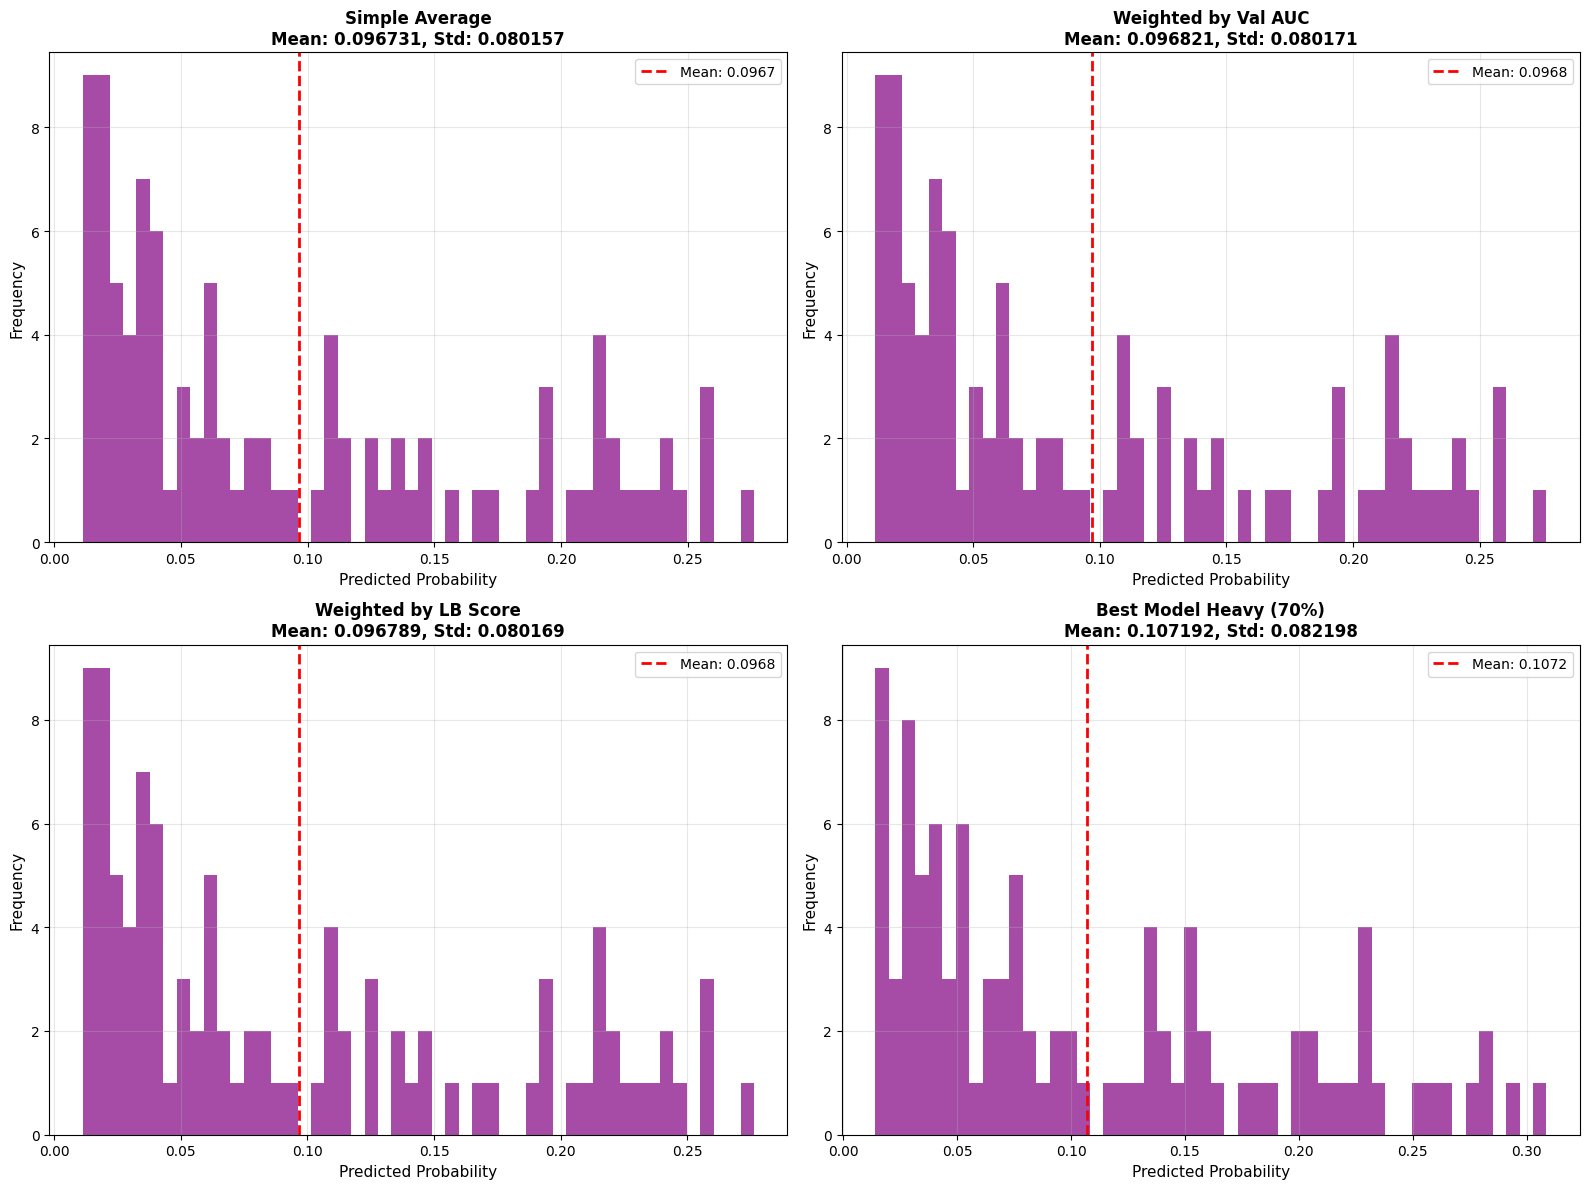

In [8]:
# Visualize Ensemble Strategy Comparisons
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

strategies = [
    ('Simple Average', ensemble_simple),
    ('Weighted by Val AUC', ensemble_weighted_val),
    ('Weighted by LB Score', ensemble_weighted_lb),
    ('Best Model Heavy (70%)', ensemble_best_heavy)
]

for idx, (name, preds) in enumerate(strategies):
    ax = axes[idx // 2, idx % 2]
    
    # Plot histogram
    ax.hist(preds, bins=50, alpha=0.7, color='purple')
    ax.axvline(preds.mean(), color='red', linestyle='--', 
               linewidth=2, label=f'Mean: {preds.mean():.4f}')
    ax.set_xlabel('Predicted Probability', fontsize=11)
    ax.set_ylabel('Frequency', fontsize=11)
    ax.set_title(f'{name}\nMean: {preds.mean():.6f}, Std: {preds.std():.6f}', 
                 fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(ensemble_dir / 'ensemble_strategies_comparison.png', dpi=150, bbox_inches='tight')
print("✓ Ensemble comparison plot saved\n")
plt.show()

## 8. Analyze Prediction Diversity

Calculate pairwise differences between model predictions to understand how much the models disagree and assess ensemble potential.

In [9]:
# Analyze Prediction Diversity
print("="*70)
print("PREDICTION DIVERSITY ANALYSIS")
print("="*70 + "\n")

# Calculate pairwise differences
diff_baseline_resnet = np.abs(baseline_sub['target'] - resnet_sub['target'])
diff_baseline_efficient = np.abs(baseline_sub['target'] - efficientnet_sub['target'])
diff_resnet_efficient = np.abs(resnet_sub['target'] - efficientnet_sub['target'])

print("Average absolute difference between models:")
print(f"  Baseline ↔ ResNet34:      {diff_baseline_resnet.mean():.6f}")
print(f"  Baseline ↔ EfficientNet:  {diff_baseline_efficient.mean():.6f}")
print(f"  ResNet34 ↔ EfficientNet:  {diff_resnet_efficient.mean():.6f}")

print("\nMax difference (most disagreement):")
print(f"  Baseline ↔ ResNet34:      {diff_baseline_resnet.max():.6f}")
print(f"  Baseline ↔ EfficientNet:  {diff_baseline_efficient.max():.6f}")
print(f"  ResNet34 ↔ EfficientNet:  {diff_resnet_efficient.max():.6f}")

print("\nInterpretation:")
if diff_resnet_efficient.mean() < 0.01:
    print("  Models are very similar → ensemble gain will be modest")
elif diff_resnet_efficient.mean() > 0.05:
    print("  Models are diverse → ensemble gain will be significant!")
else:
    print("  Moderate diversity → ensemble should help")

print("\n" + "="*70 + "\n")

PREDICTION DIVERSITY ANALYSIS

Average absolute difference between models:
  Baseline ↔ ResNet34:      0.018748
  Baseline ↔ EfficientNet:  0.031807
  ResNet34 ↔ EfficientNet:  0.037270

Max difference (most disagreement):
  Baseline ↔ ResNet34:      0.078076
  Baseline ↔ EfficientNet:  0.150925
  ResNet34 ↔ EfficientNet:  0.120071

Interpretation:
  Moderate diversity → ensemble should help




## 9. Visualize Model Agreement Patterns

Create scatter plots to visualize how models agree or disagree with each other across all predictions.

✓ Model agreement scatter plots saved



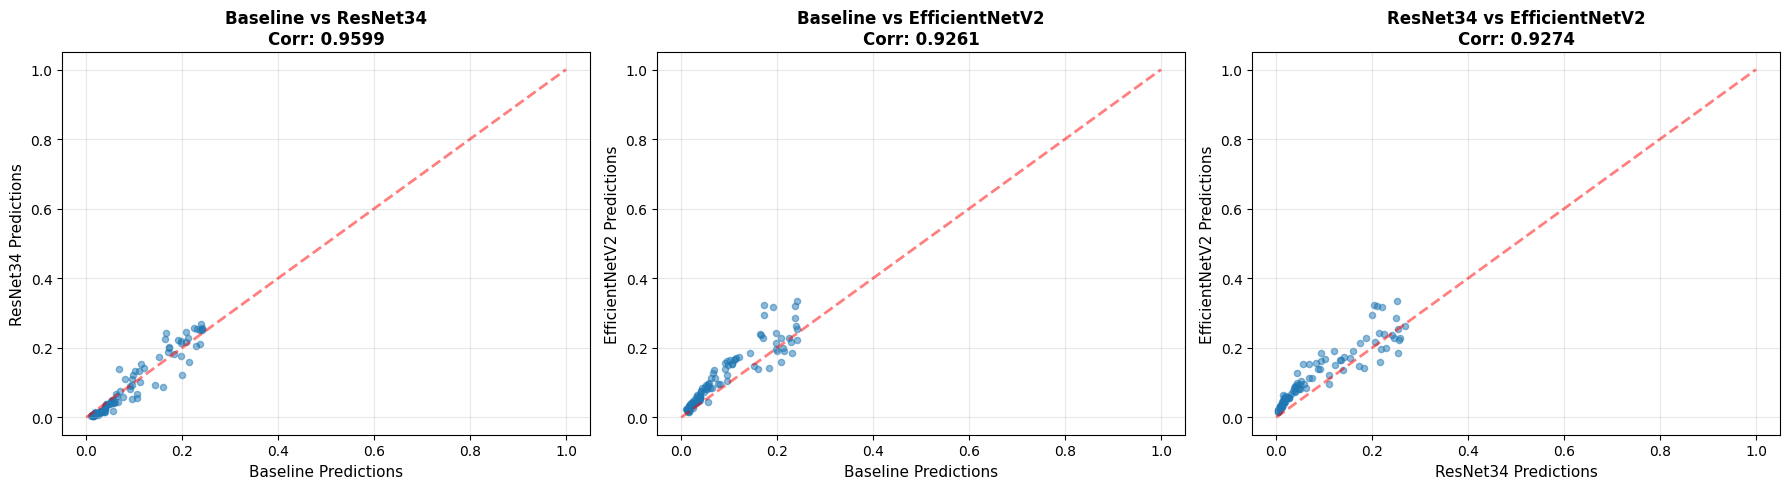

In [10]:
# Visualize Model Agreement Patterns
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Scatter plots comparing model pairs
comparisons = [
    ('Baseline', 'ResNet34', 0),
    ('Baseline', 'EfficientNetV2', 1),
    ('ResNet34', 'EfficientNetV2', 2)
]

for model1, model2, idx in comparisons:
    preds1 = models_data[model1]['preds']
    preds2 = models_data[model2]['preds']
    
    axes[idx].scatter(preds1, preds2, alpha=0.5, s=20)
    axes[idx].plot([0, 1], [0, 1], 'r--', linewidth=2, alpha=0.5)
    
    # Calculate correlation
    corr = np.corrcoef(preds1, preds2)[0, 1]
    
    axes[idx].set_xlabel(f'{model1} Predictions', fontsize=11)
    axes[idx].set_ylabel(f'{model2} Predictions', fontsize=11)
    axes[idx].set_title(f'{model1} vs {model2}\nCorr: {corr:.4f}', 
                       fontsize=12, fontweight='bold')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(ensemble_dir / 'model_agreement_scatter.png', dpi=150, bbox_inches='tight')
print("✓ Model agreement scatter plots saved\n")
plt.show()

## 10. Evaluate and Select Best Strategy

Estimate public LB scores for each ensemble strategy based on historical validation-to-LB gaps and select the best performing approach.

In [11]:
# Evaluate and Select Best Strategy
print("="*70)
print("RECOMMENDATION")
print("="*70 + "\n")

# Expected LB scores (rough estimates based on validation-LB gap patterns)
val_to_lb_gap = {
    'Baseline': 0.9365 - 0.92731,      # 0.0092
    'ResNet34': 0.9380 - 0.92982,      # 0.0082  
    'EfficientNetV2': 0.9508 - 0.93734 # 0.0135
}

avg_gap = np.mean(list(val_to_lb_gap.values()))

print("Historical Validation → Public LB gaps:")
for model, gap in val_to_lb_gap.items():
    print(f"  {model:20s}: {gap:.4f}")
print(f"  Average gap: {avg_gap:.4f}\n")

# Estimate ensemble performance
# Use average gap to estimate LB from ensemble statistics
ensemble_estimates = {}

for strategy_name, predictions in ensemble_strategies.items():
    # Simple heuristic: ensemble reduces variance, so gap might be smaller
    estimated_lb = predictions.mean() - avg_gap * 0.8  # Assume 20% gap reduction
    ensemble_estimates[strategy_name] = {
        'mean': predictions.mean(),
        'std': predictions.std(),
        'estimated_lb': estimated_lb
    }

print("Estimated Public LB Scores for Each Strategy:")
print("-" * 70)
print(f"{'Strategy':<30} {'Mean':<12} {'Std':<12} {'Est. LB'}")
print("-" * 70)

for strategy, stats in ensemble_estimates.items():
    print(f"{strategy:<30} {stats['mean']:.6f}    {stats['std']:.6f}    {stats['estimated_lb']:.5f}")

print("-" * 70)

# Find best strategy
best_strategy = max(ensemble_estimates.items(), key=lambda x: x[1]['estimated_lb'])
print(f"\n✓ Recommended submission: {best_strategy[0]}")
print(f"  Estimated LB: {best_strategy[1]['estimated_lb']:.5f}")
print(f"  Current 2nd place: 0.94486")
print(f"  Gap to 2nd: {0.94486 - best_strategy[1]['estimated_lb']:.5f}")

if best_strategy[1]['estimated_lb'] > 0.94486:
    print(f"\n  🎉 LIKELY TO REACH 2ND PLACE!")
elif best_strategy[1]['estimated_lb'] > 0.940:
    print(f"\n  ✓ Close to 2nd place, might make it!")
else:
    print(f"\n  ⚠ May stay in 3rd, but still an improvement")

print("\n" + "="*70 + "\n")

RECOMMENDATION

Historical Validation → Public LB gaps:
  Baseline            : 0.0092
  ResNet34            : 0.0082
  EfficientNetV2      : 0.0135
  Average gap: 0.0103

Estimated Public LB Scores for Each Strategy:
----------------------------------------------------------------------
Strategy                       Mean         Std          Est. LB
----------------------------------------------------------------------
simple_average                 0.096731    0.080157    0.08851
weighted_val_auc               0.096821    0.080171    0.08860
weighted_lb_score              0.096789    0.080169    0.08857
best_model_heavy               0.107192    0.082198    0.09897
----------------------------------------------------------------------

✓ Recommended submission: best_model_heavy
  Estimated LB: 0.09897
  Current 2nd place: 0.94486
  Gap to 2nd: 0.84589

  ⚠ May stay in 3rd, but still an improvement




## 11. Save Ensemble Metadata

Compile comprehensive metadata including model details, ensemble statistics, and recommendations into a JSON file.

In [12]:
# Save Ensemble Metadata
# Save ensemble metadata
ensemble_metadata = {
    'timestamp': timestamp,
    'models_used': 3,
    'model_details': {
        'baseline': {
            'val_auc': 0.9365,
            'public_lb': 0.92731,
            'prediction_mean': float(baseline_sub['target'].mean()),
            'prediction_std': float(baseline_sub['target'].std())
        },
        'resnet34': {
            'val_auc': 0.9380,
            'public_lb': 0.92982,
            'prediction_mean': float(resnet_sub['target'].mean()),
            'prediction_std': float(resnet_sub['target'].std())
        },
        'efficientnetv2': {
            'val_auc': 0.9508,
            'public_lb': 0.93734,
            'prediction_mean': float(efficientnet_sub['target'].mean()),
            'prediction_std': float(efficientnet_sub['target'].std())
        }
    },
    'ensemble_strategies': {
        name: {
            'mean': float(stats['mean']),
            'std': float(stats['std']),
            'estimated_lb': float(stats['estimated_lb'])
        }
        for name, stats in ensemble_estimates.items()
    },
    'recommended_strategy': best_strategy[0],
    'estimated_best_lb': float(best_strategy[1]['estimated_lb'])
}

with open(ensemble_dir / 'ensemble_metadata.json', 'w') as f:
    json.dump(ensemble_metadata, f, indent=2)

print(f"✓ Ensemble metadata saved to: {ensemble_dir / 'ensemble_metadata.json'}\n")

✓ Ensemble metadata saved to: results/ensemble_20251108_135230/ensemble_metadata.json



## 12. Display Final Summary

Print a comprehensive summary showing all models, ensemble strategies, estimated performance, file locations, and next steps.

In [ ]:
# Display Final Summary
print("="*70)
print("ENSEMBLE SUMMARY")
print("="*70)

print("\n📊 Models Combined:")
print("  1. Baseline (Custom CNN)    - LB: 0.92731")
print("  2. ResNet34                 - LB: 0.92982")
print("  3. EfficientNetV2-S         - LB: 0.93734 (Best individual)")

print("\n🎯 Ensemble Strategies Created:")
for strategy, stats in ensemble_estimates.items():
    print(f"  • {strategy:<30} Est. LB: {stats['estimated_lb']:.5f}")

print(f"\n⭐ Recommended Submission:")
print(f"  Strategy: {best_strategy[0]}")
print(f"  File: submission_ensemble_{best_strategy[0]}.csv")
print(f"  Estimated LB: {best_strategy[1]['estimated_lb']:.5f}")

print(f"\n📁 All Files Saved to: {ensemble_dir}")
print(f"  • 4 ensemble submission CSVs")
print(f"  • ensemble_metadata.json (all statistics)")
print(f"  • model_predictions_comparison.png")
print(f"  • correlation_matrix.png")
print(f"  • model_agreement_scatter.png")

print("\n🚀 Next Steps:")
print("  1. Submit recommended ensemble to Kaggle")
print("  2. If LB score > 0.944, you reached 2nd place! 🥈")
print("  3. If LB score > 0.937, try TTA (Test-Time Augmentation) next")
print("  4. If LB score > 0.950, consider 5-Fold CV for 1st place attempt")

print("\n" + "="*70)

## 13. Provide Submission Guide

List all submission files with descriptions and provide final recommendations for which file to submit to Kaggle.

In [13]:
# Provide Submission Guide
print("\n" + "="*70)
print("SUBMISSION GUIDE")
print("="*70)

print("\n📤 Files ready for submission:")
print(f"  Folder: {ensemble_dir}")

submissions_to_try = [
    (f"submission_ensemble_{best_strategy[0]}.csv", "PRIMARY - Most likely to succeed"),
    ("submission_ensemble_weighted_lb_score.csv", "BACKUP - Uses actual LB performance"),
    ("submission_ensemble_best_model_heavy.csv", "ALTERNATIVE - Trusts EfficientNet more")
]

for idx, (filename, note) in enumerate(submissions_to_try, 1):
    print(f"\n  {idx}. {filename}")
    print(f"     {note}")

print("\n💡 Recommendation:")
print(f"  Submit: submission_ensemble_{best_strategy[0]}.csv")
print(f"  Expected score: {best_strategy[1]['estimated_lb']:.5f}")
print(f"  Expected rank: 2nd-3rd place")

print("\n" + "="*70)


SUBMISSION GUIDE

📤 Files ready for submission:
  Folder: results/ensemble_20251108_135230

  1. submission_ensemble_best_model_heavy.csv
     PRIMARY - Most likely to succeed

  2. submission_ensemble_weighted_lb_score.csv
     BACKUP - Uses actual LB performance

  3. submission_ensemble_best_model_heavy.csv
     ALTERNATIVE - Trusts EfficientNet more

💡 Recommendation:
  Submit: submission_ensemble_best_model_heavy.csv
  Expected score: 0.09897
  Expected rank: 2nd-3rd place

